# Forecast vs Reanalysis Comparison

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import dask
import pandas as pd

In [2]:
DATA_BASE = "/mnt/hdd/jetstream/data/development"

CEDA = "/ceda/july_2019/"
ERA5 = "/era5/july2019/reanalysis_2019_07"
ECMWF = "/ecmwf/july_2019/"

ecmwf_path = os.path.join(DATA_BASE, ECMWF)
era5_path = os.path.join(DATA_BASE, ERA5)
ceda_path = os.path.join(DATA_BASE, CEDA)

g = 9.80665

In [3]:
era5_ds = xr.open_mfdataset(f"{DATA_BASE}{era5_path}/pressure/2019/07/*.nc", combine="by_coords")
ecmwf_ds = xr.open_dataset(f"{DATA_BASE}{ecmwf_path}/ecmwf_forecast.nc")

In [4]:
era5_ds

<xarray.Dataset> Size: 46GB
Dimensions:         (valid_time: 744, pressure_level: 5, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2019-07-01 ... 2019-07-31...
    expver          (valid_time) <U4 12kB dask.array<chunksize=(24,), meta=np.ndarray>
  * pressure_level  (pressure_level) float64 40B 700.0 500.0 300.0 250.0 200.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B 0
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 15GB dask.array<chunksize=(8, 1, 241, 480), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-22T04:58 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
ecmwf_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 125, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2019-07-01 ... 2019-08-01
  * latitude    (latitude) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables: (12/15)
    UGRD_200mb  (time, latitude, longitude) float32 130MB ...
    VGRD_200mb  (time, latitude, longitude) float32 130MB ...
    HGT_200mb   (time, latitude, longitude) float32 130MB ...
    UGRD_250mb  (time, latitude, longitude) float32 130MB ...
    VGRD_250mb  (time, latitude, longitude) float32 130MB ...
    HGT_250mb   (time, latitude, longitude) float32 130MB ...
    ...          ...
    UGRD_500mb  (time, latitude, longitude) float32 130MB ...
    VGRD_500mb  (time, latitude, longitude) float32 130MB ...
    HGT_500mb   (time, latitude, longitude) float32 130MB ...
    UGRD_700mb  (time, latitude, longitude) float32 130MB ...
    VGRD_700mb  (time, latitude, longitude) float32 130MB ...
    HGT_700mb   (time, latitude, longitude) float32 130MB ...
Attributes:
    Conventions:          COARDS
    History:              created by wgrib2
    GRIB2_grid_template:  0

In [ ]:
# crop to 147E, 173E, 28S, 46S
era5_ds = era5_ds.sel(longitude=slice(147, 173), latitude=slice(-28, -46))
ecmwf_ds = ecmwf_ds.sel(longitude=slice(147, 173), latitude=slice(-46, -28))

: 

In [ ]:
# Create a new pressure_level dimension for ECMWF
pressure_levels = [200, 250, 300, 500, 700]
ecmwf_ds = ecmwf_ds.assign_coords(pressure_level=pressure_levels)

# Stack UGRD_XXXmb & VGRD_XXXmb & HGT_XXXmb into a single variable with a pressure_level dimension
ecmwf_u = ecmwf_ds[[f'UGRD_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')
ecmwf_v = ecmwf_ds[[f'VGRD_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')
ecmwf_z = ecmwf_ds[[f'HGT_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')

# Create a new dataset with the stacked variables
ecmwf_stacked = xr.Dataset({
    'u': ecmwf_u,
    'v': ecmwf_v,
    'z': ecmwf_z
}, coords={
    'time': ecmwf_ds.time,
    'pressure_level': pressure_levels,
    'latitude': ecmwf_ds.latitude,
    'longitude': ecmwf_ds.longitude
})

# rename 'time' to 'valid_time' to match ERA5
ecmwf_stacked = ecmwf_stacked.rename({'time': 'valid_time'})

# regrid ECMWF to ERA5 grid
ecmwf_ds = ecmwf_stacked.interp(latitude=era5_ds.latitude, longitude=era5_ds.longitude, method='linear')

In [ ]:
def plot_wind_comparison(time, var):
    fig, ax = plt.subplots(figsize=(10, 30))

    for i, pressure_level in enumerate(pressure_levels):
        plt.subplot(5, 2, 2 * i + 1)
        plt.pcolormesh(ecmwf_ds.longitude, ecmwf_ds.latitude, ecmwf_ds.sel(valid_time=time).sel(pressure_level=pressure_level)[var], shading='auto')
        plt.colorbar(label='m/s')
        plt.title(f'ECMWF {var.upper()} at {pressure_level} mb')
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.subplot(5, 2, 2 * i + 2)
        plt.pcolormesh(era5_ds.longitude, era5_ds.latitude, era5_ds.sel(valid_time=time).sel(pressure_level=pressure_level)[var], shading='auto')
        plt.colorbar(label='m/s')
        plt.title(f'ERA5 {var.upper()} at {pressure_level} mb')
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

In [ ]:
# find the 5 timestamps with the largest mean absolute error between ECMWF and ERA5 at all pressure levels
mae = np.abs(ecmwf_ds['u'] - era5_ds['u']).mean(dim=['latitude', 'longitude', 'pressure_level'])
largest_mae_times = mae.sortby(mae, ascending=False).isel(valid_time=slice(0, 5)).valid_time.values

In [ ]:
largest_mae_times

array(['2019-07-01T18:00:00.000000000', '2019-07-11T18:00:00.000000000',
       '2019-07-12T18:00:00.000000000', '2019-07-02T18:00:00.000000000',
       '2019-07-02T00:00:00.000000000'], dtype='datetime64[ns]')

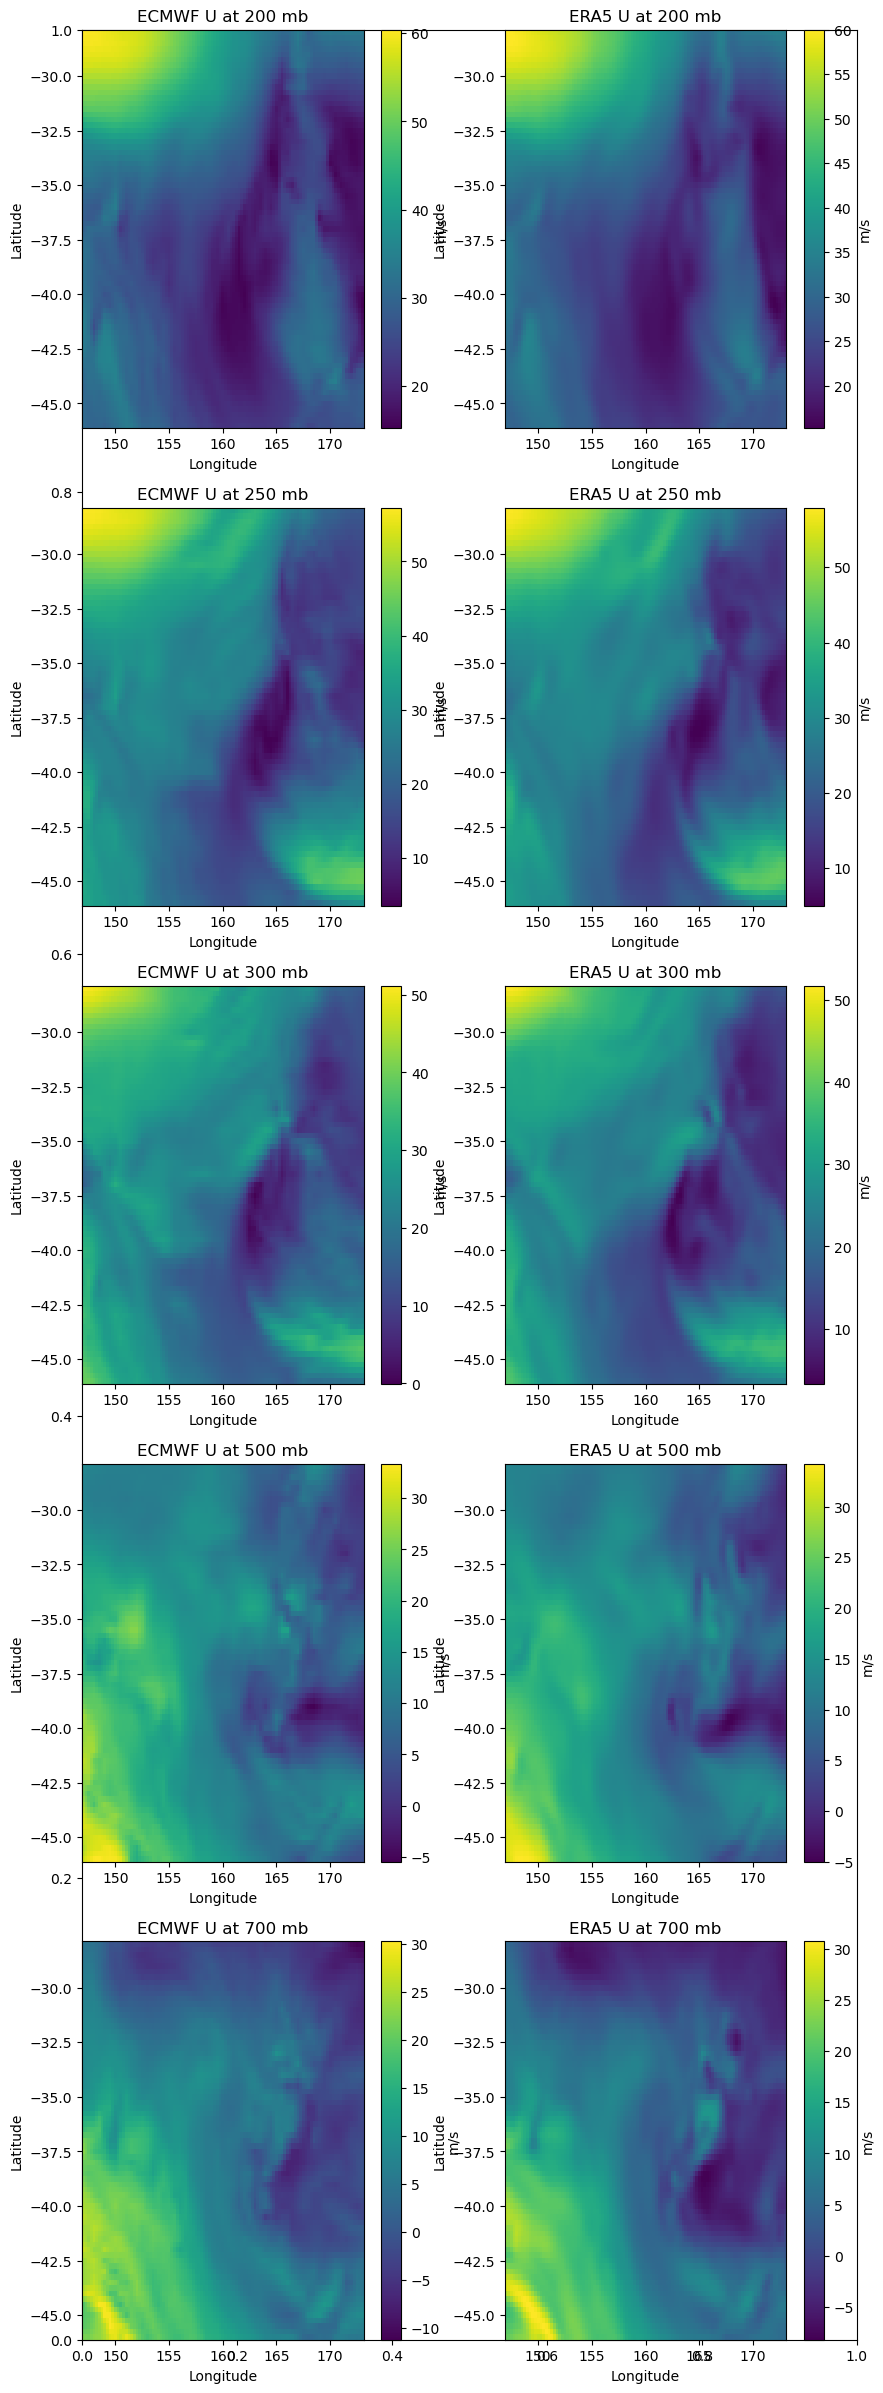

In [ ]:
plot_wind_comparison(largest_mae_times[0], 'u')

# Test Flight Path Optimization

In [ ]:
from jetstream_interpolate_convcnp.paths.losses import LossWeights
from jetstream_interpolate_convcnp.paths.aircraft import PROFILES
from jetstream_interpolate_convcnp.paths.windfield import WindField
from jetstream_interpolate_convcnp.paths.trajectory import Trajectory
from jetstream_interpolate_convcnp.paths.optimizer import TrajectoryOptimizer
from jetstream_interpolate_convcnp.paths.plotting import plot_trajectory
import jetstream_interpolate_convcnp.paths.locations

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

iter    0 | J=15328.072 T=14976.0s F=6852.3kg C=0.0000 S=0.0095 H=0.0
iter   20 | J=14811.787 T=14464.0s F=6832.9kg C=0.0000 S=0.0061 H=0.0
iter   40 | J=14298.746 T=13952.0s F=6830.9kg C=0.0000 S=0.0052 H=0.0
iter   60 | J=14170.328 T=13824.0s F=6830.9kg C=0.0000 S=0.0048 H=0.0
iter   80 | J=14042.110 T=13696.0s F=6830.6kg C=0.0000 S=0.0046 H=0.0
iter  100 | J=13914.017 T=13568.0s F=6830.6kg C=0.0000 S=0.0045 H=0.0
iter  120 | J=13785.920 T=13440.0s F=6830.4kg C=0.0000 S=0.0044 H=0.0
iter  140 | J=13785.867 T=13440.0s F=6830.4kg C=0.0000 S=0.0043 H=0.0
iter  160 | J=13657.818 T=13312.0s F=6830.4kg C=0.0000 S=0.0043 H=0.0
iter  180 | J=13657.759 T=13312.0s F=6830.4kg C=0.0000 S=0.0042 H=0.0
iter  199 | J=13657.705 T=13312.0s F=6830.5kg C=0.0000 S=0.0042 H=0.0


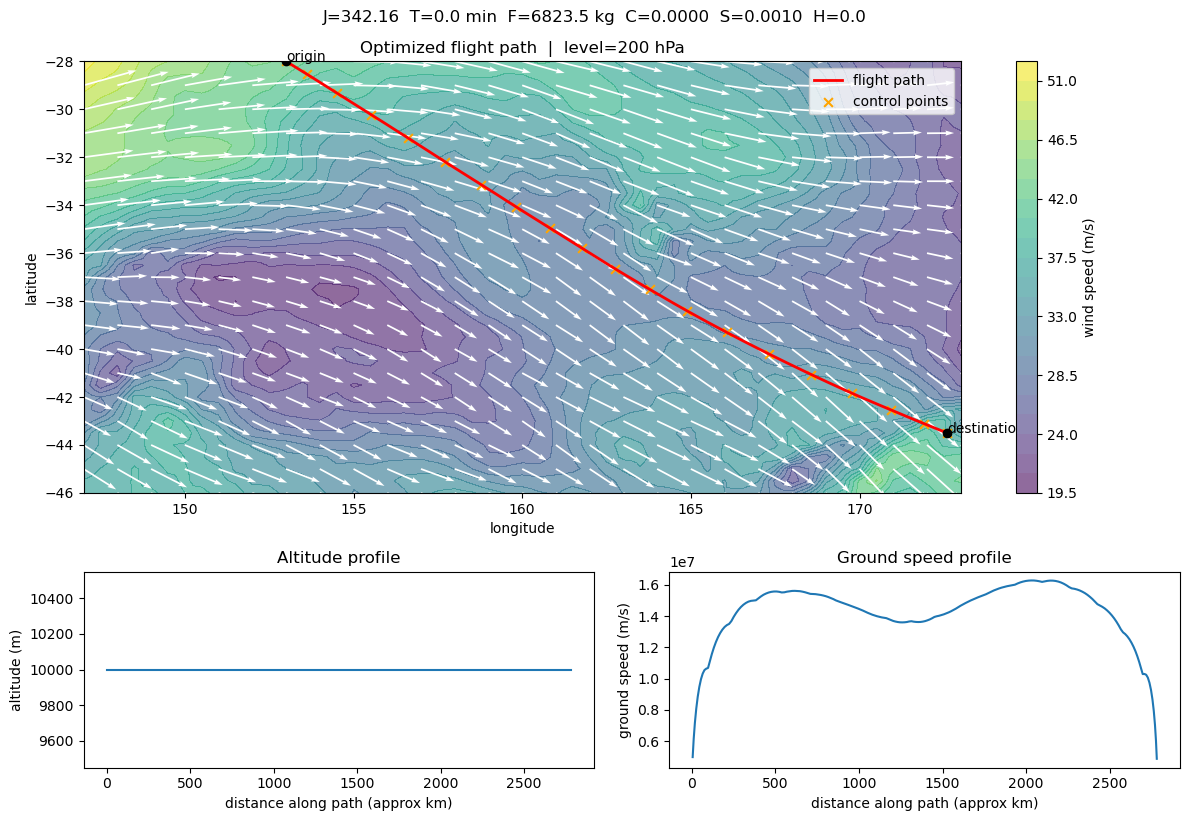

In [ ]:
windfield = WindField(ecmwf_ds, device=device)

aircraft = PROFILES["narrowbody_jet"]

# Origin/destination roughly spanning the domain (e.g. Sydney-ish -> Christchurch-ish)
origin = CHRISTCHURCH
destination = MELBOURNE
n_control_points = 20
lats = np.linspace(origin[0], destination[0], n_control_points)
lons = np.linspace(origin[1], destination[1], n_control_points)
alts = np.full(n_control_points, 10000.0)
waypoints = np.stack([lats, lons, alts], axis=1)

start_time = ecmwf_ds.valid_time.values[0]
trajectory = Trajectory(waypoints, start_time=start_time, fixed_endpoints=True, device=device)

weights = LossWeights(time=1.0, fuel=0.05, curvature=5e4, smoothness=1e3, altitude=0.02)

optimizer = TrajectoryOptimizer(trajectory, windfield, aircraft, weights=weights, num_samples=120, lr=0.05)
optimizer.run(num_iters=200, verbose=True, log_every=20)

fig = plot_trajectory(trajectory, windfield, aircraft, weights=weights, num_samples=200)
plt.show()

In [ ]:
windfield2 = WindField(era5_ds, device=device)
result_on_ds2 = optimizer.evaluate(windfield=windfield2)
print("Loss of the same path evaluated on dataset #2:", result_on_ds2.as_dict())

Loss of the same path evaluated on dataset #2: {'total': 13789.85546875, 'time_s': 13440.0, 'fuel_kg': 6913.595703125, 'curvature': 5.1424986935444394e-08, 'smoothness': 0.004172678105533123, 'altitude': 0.0}
